In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
Germline = "HaPMAP_overlapping_germline_full.txt"

In [3]:
Reference = "HaPMAP_overlapping_reference_full.txt"

In [4]:
Somatic = "HaPMAP_somatic_candidates_full.txt"

In [5]:
PALMER_Calls = "HapMapmerged_numts_calls.txt"

In [6]:
def plotting(file, title):
    calls_df = pd.read_csv(file, sep='\t', header=None)

    calls_df.columns = [
        'chr', 'start1', 'end1', 'chr_p', 'start1_p', 'end1_p',
        'cluster_id', 'Potential_supporting_reads', 'polyA_tail_TSD'
    ]

    max_reads = calls_df['Potential_supporting_reads'].max()

    plt.hist(
        calls_df['Potential_supporting_reads'],
        range=(2, max_reads),
        bins=100,
        histtype='bar',
        log=True
    )

    plt.xlabel('Potential Supporting Reads')
    plt.ylabel('Frequency')
    plt.title(f'Histogram {title}')
    plt.tight_layout()
    plt.show()


In [7]:
#pd.read_csv(all_somatic, sep='\t', header = None)

In [8]:
    calls_df = pd.read_csv(Somatic, sep='\t', header=None)

    calls_df.columns = [
        'chr', 'start1', 'end1', 'chr_p', 'start1_p', 'end1_p',
        'cluster_id', 'Potential_supporting_reads', 'polyA_tail_TSD'
    ]

# Get the minimum value
min_val = calls_df['Potential_supporting_reads'].min()

# Count how many times it occurs
count_min = (calls_df['Potential_supporting_reads'] == min_val).sum()

print(f"The minimum value {min_val} occurs {count_min} times.")

The minimum value 1 occurs 101888 times.


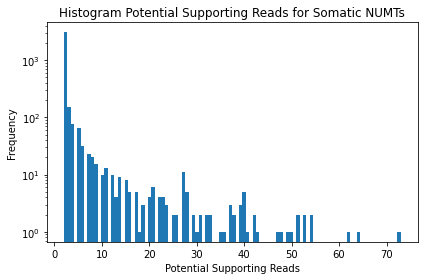

In [9]:
plotting(Somatic, "Potential Supporting Reads for Somatic NUMTs")

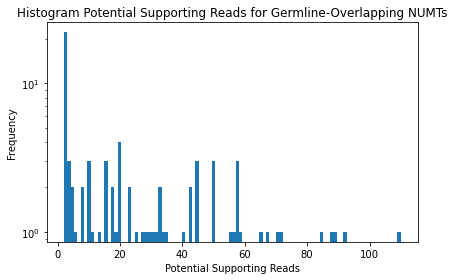

In [10]:
plotting(Germline, "Potential Supporting Reads for Germline-Overlapping NUMTs")

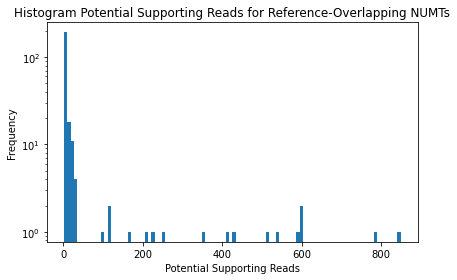

In [11]:
plotting(Reference, "Potential Supporting Reads for Reference-Overlapping NUMTs")

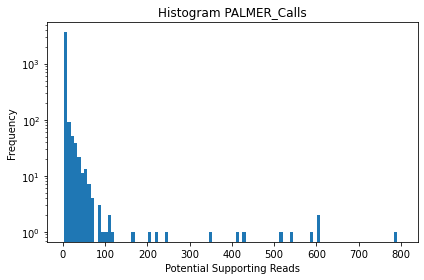

In [12]:
    calls_df =pd.read_csv(PALMER_Calls, sep='\t')
    plt.hist(
        calls_df['Potential_supporting_reads'],

        range=(2,800),  
        histtype='bar',
        bins = 100,
        log= True
        )

    plt.xlabel('Potential Supporting Reads')
    plt.ylabel('Frequency')
    plt.title('Histogram PALMER_Calls')
    plt.tight_layout()
    plt.show()
    

In [13]:

min_val = calls_df['Potential_supporting_reads'].min()

# Count how many times it occurs
count_min = (calls_df['Potential_supporting_reads'] == min_val).sum()

print(f"The minimum value {min_val} occurs {count_min} times.")

The minimum value 1 occurs 102473 times.


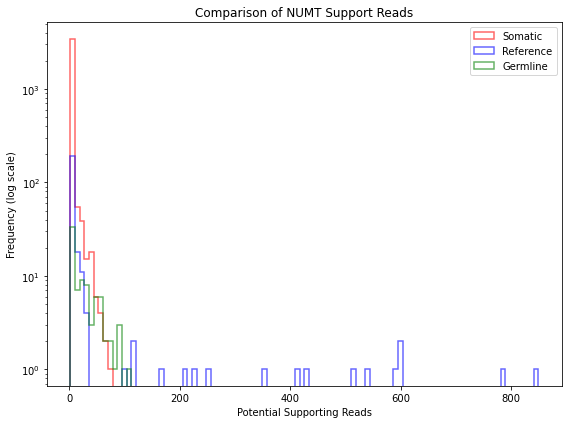

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

def plotting_multiple(files, labels, colors=None):
    """
    Plot overlapping histograms of Potential Supporting Reads for multiple NUMT datasets.
    
    files: list of file paths (e.g., [somatic, reference, germline])
    labels: list of labels for the legend
    colors: optional list of colors for each histogram
    """
    plt.figure(figsize=(8,6))
    
    if colors is None:
        colors = ['red', 'blue', 'green']  # default colors

    max_reads = 0
    # Find the global max to use the same range for all
    for file in files:
        df = pd.read_csv(file, sep='\t', header=None)
        df.columns = [
            'chr', 'start1', 'end1', 'chr_p', 'start1_p', 'end1_p',
            'cluster_id', 'Potential_supporting_reads', 'polyA_tail_TSD'
        ]
        max_reads = max(max_reads, df['Potential_supporting_reads'].max())
    
    # Plot each histogram
    for file, label, color in zip(files, labels, colors):
        df = pd.read_csv(file, sep='\t', header=None)
        df.columns = [
            'chr', 'start1', 'end1', 'chr_p', 'start1_p', 'end1_p',
            'cluster_id', 'Potential_supporting_reads', 'polyA_tail_TSD'
        ]
        plt.hist(
            df['Potential_supporting_reads'],
            range=(2, max_reads),
            bins=100,
            histtype='step',  # outline so histograms don’t block each other
            alpha = .6,
            linewidth=1.5,
            label=label,
            color=color,
            log=True
        )
    
    plt.xlabel('Potential Supporting Reads')
    plt.ylabel('Frequency (log scale)')
    plt.title('Comparison of NUMT Support Reads')
    plt.legend()
    plt.tight_layout()
    plt.show()


# Example usage:
files = ['HaPMAP_somatic_candidates_full.txt', 'HaPMAP_overlapping_reference_full.txt', 'HaPMAP_overlapping_germline_full.txt']
labels = ['Somatic', 'Reference', 'Germline']
plotting_multiple(files, labels)
